SVM -- HARD MARGIN


In [153]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(15)

# Clase +1
X1 = np.random.randn(20,2)*0.5 + np.array([2,2])

# Clase -1
X2 = np.random.randn(20,2)*0.5 + np.array([-2,-2])

X = np.vstack((X1,X2))

t = np.hstack((np.ones(20),-np.ones(20)))

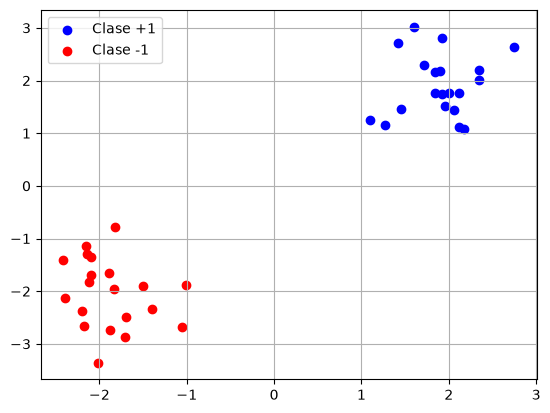

In [154]:
plt.scatter(X1[:,0],X1[:,1],color='blue',label='Clase +1')  
plt.scatter(X2[:,0],X2[:,1],color="red", label="Clase -1")
plt.legend()
plt.grid()
plt.show()


In [155]:
def kernerl(X):
    return X@X.T

In [156]:
K=kernerl(X)

In [157]:
z=np.outer(t,t)*K

In [158]:
alphas = np.random.rand(len(t))
def objective(alphas):
    L=np.sum(alphas) - alphas@z@alphas
    return -L


In [159]:
cons =({"type":"eq","fun": lambda alphas: np.sum(alphas*t)})
bounds=((0,None),)*len(alphas)

In [160]:
alphas_opt= minimize(objective,alphas,constraints=cons,bounds=bounds)
a=alphas_opt.x

In [161]:
sv= a > 1e-5

In [162]:
X.shape

(40, 2)

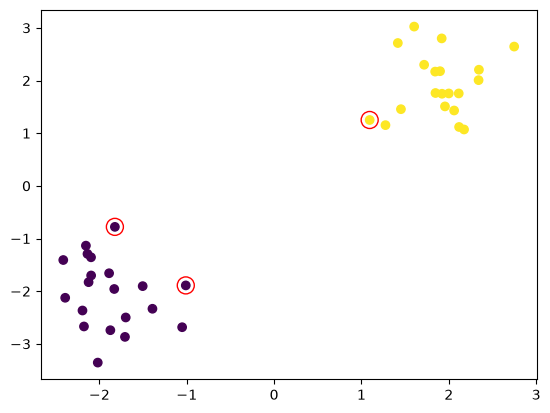

In [163]:
plt.scatter(
X[:,0],
X[:,1],
c=t
)

plt.scatter(
X[sv,0],
X[sv,1],
s=150,
facecolors='none',
edgecolors='red'
)

In [164]:
w=np.sum((a*t)[:,None]*X,axis=0)
b=np.mean(t[sv]-X[sv]@w)

In [165]:
x1=np.linspace(-4,4,100)
x2=-(w[0]*x1+b)/w[1]

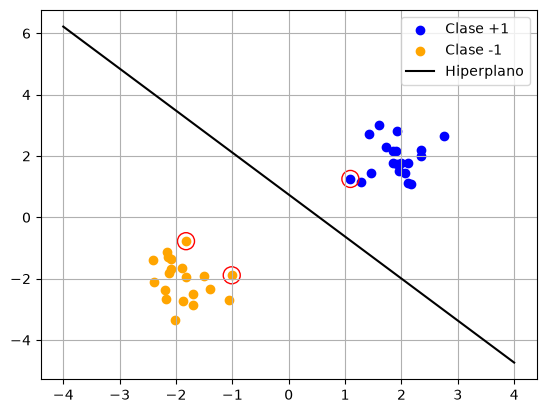

In [166]:
plt.scatter(X1[:,0],X1[:,1],color='blue',label='Clase +1')
plt.scatter(X2[:,0],X2[:,1], color="orange", label="Clase -1")

plt.scatter(
X[sv,0],
X[sv,1],
s=150,
facecolors='none',
edgecolors='red'
)
plt.plot(x1,x2,color='black',label='Hiperplano') 
plt.grid()
plt.legend() 
plt.show() 
         